In [293]:
# Імпортуємо необхідні бібліотеки
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg # Для завантаження та збереження зображень

# Налаштування для кращого відображення в Jupyter
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

### Крок 1: Завантаження зображень і налаштування  виводу  

In [294]:
try:
    img_object_orig = mpimg.imread('test.PNG')
    img_object_orig2 = mpimg.imread('natural-composition-with-two-pink-flowers-floral-hearts_23-2147601167.jpg')
    img_background = mpimg.imread('Background.webp')
except FileNotFoundError:
    print("ПОМИЛКА: Файли 'object.png' та 'background.png' не знайдені.")
    print("Будь ласка, завантажте ваші зображення у ту ж папку, що і цей ноутбук.")
    # Створимо 'ячейки', щоб код міг працювати для демонстрації
    # Для 1 зображення 
    img_object_orig = np.full((300, 300, 3), 0.2, dtype=np.float32)
    img_object_orig[75:225, 75:225, :] = 0.8
    #Для 2 зображення 
    img_object_orig2 = np.full((300, 300, 3), 0.2, dtype=np.float32)
    img_object_orig2[75:225, 75:225, :] = 0.8
    #Для фону
    img_background = np.full((500, 500, 3), 0.1, dtype=np.float32)
    img_background[:, :, 1] = 0.5

#### Перевіряємо, чи є 4-й канал (Alpha) у зображеннях

In [295]:
if img_object_orig.ndim == 3 and img_object_orig.shape[2] == 4:
    print("Знайдено у 1 4 канали (RGBA) у 'object.png'. Відкидаємо Alpha-канал.")
    img_object_orig = img_object_orig[:, :, :3]  # Беремо лише перші 3 канали (R, G, B)

if img_object_orig2.ndim == 3 and img_object_orig2.shape[2] == 4:
    print("Знайдено у 2 4 канали (RGBA) у 'object.png'. Відкидаємо Alpha-канал.")
    img_object_orig2 = img_object_orig2[:, :, :3] 
    
if img_background.ndim == 3 and img_background.shape[2] == 4:
    print("Знайдено у фоні 4 канали (RGBA) у 'background.png'. Відкидаємо Alpha-канал.")
    img_background = img_background[:, :, :3]

Знайдено у 1 4 канали (RGBA) у 'object.png'. Відкидаємо Alpha-канал.


#### Нормалізуємо все до float [0, 1] для узгодженості.

In [296]:
if img_object_orig.dtype == np.uint8:
  img_object_orig = img_object_orig / 255.0

if img_object_orig2.dtype == np.uint8:
   img_object_orig2 = img_object_orig2 / 255.0
    
if img_background.dtype == np.uint8:
  img_background = img_background / 255.0

#### Відобразимо завантажені зображення

Завантажено зображення об'єкта, розмір: (249, 249, 3)
Завантажено зображення 2 об'єкта, розмір: (493, 740, 3)
Завантажено зображення фону, розмір: (325, 600, 3)


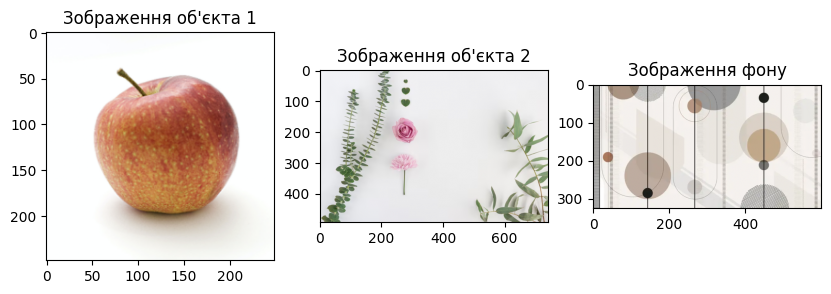

In [297]:
print(f"Завантажено зображення об'єкта, розмір: {img_object_orig.shape}")
print(f"Завантажено зображення 2 об'єкта, розмір: {img_object_orig2.shape}")
print(f"Завантажено зображення фону, розмір: {img_background.shape}")


plt.subplot(1, 3, 1)
plt.imshow(img_object_orig)
plt.title("Зображення об'єкта 1")
plt.subplot(1, 3, 2)
plt.imshow(img_object_orig2)
plt.title("Зображення об'єкта 2")
plt.subplot(1, 3, 3)
plt.imshow(img_background)
plt.title("Зображення фону")
plt.show()

### Крок 2: Обрізання зображення (Cropping)

Вибираєм координати для обрізання
    a: верхня межа, b: нижня межа     (y)
    c: ліва межа, d: права межа       (x)

Розмір тестового обрізаного зображення: (120, 130, 3)
Розмір власного обрізаного зображення: (343, 430, 3)


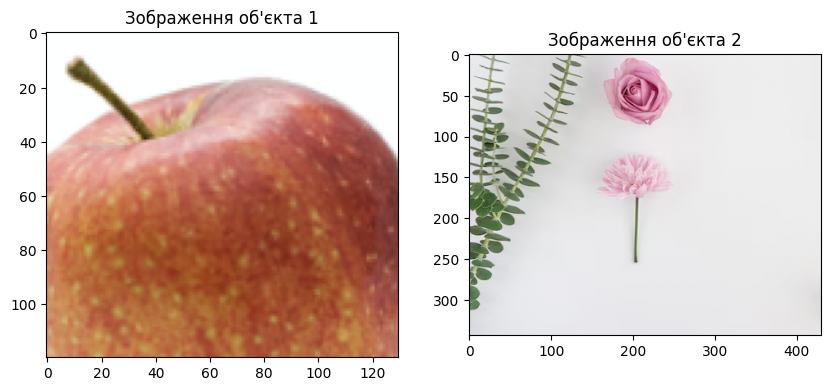

In [ ]:
a, b = 30, 150
c, d = 70, 200

img_cropped = img_object_orig[a:b, c:d]        

a, b = 150, 500
c, d = 70, 500

img_cropped2 = img_object_orig2[a:b, c:d]      

print(f"Розмір тестового обрізаного зображення: {img_cropped.shape}")
print(f"Розмір власного обрізаного зображення: {img_cropped2.shape}")
plt.subplot(1, 2, 1)
plt.imshow(img_cropped)
plt.title("Зображення об'єкта 1")
plt.subplot(1, 2, 2)
plt.imshow(img_cropped2)
plt.title("Зображення об'єкта 2")
plt.show()

### Крок 3: Конвертація в чорно-білий (Grayscale)

Розмір ч/б тестового обрізаного зображення: (120, 130, 3)
Розмір ч/б власного обрізаного зображення: (343, 430, 3)


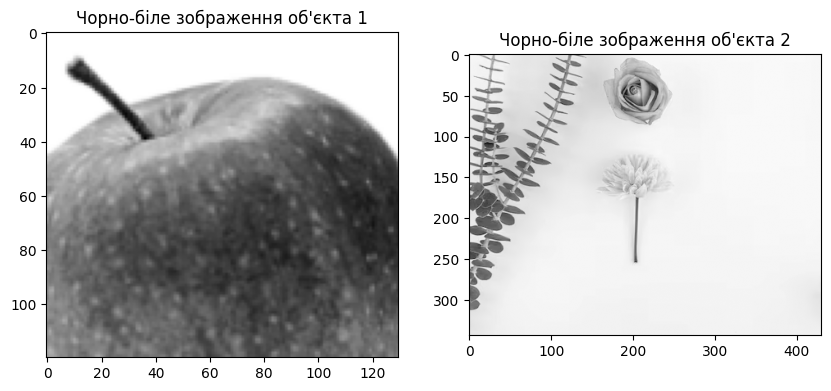

In [299]:
def rgb_to_gray(img_rgb):
  # Використовує стандартну формулу Luminosity :  Y = 0.299*R + 0.587*G + 0.114*B
   
    r = img_rgb[:, :, 0]
    g = img_rgb[:, :, 1]
    b = img_rgb[:, :, 2]
    
    img_gray = 0.299 * r + 0.587 * g + 0.114 * b
    
    return img_gray

img_gray1 = rgb_to_gray(img_cropped) # Конвертуємо наше обрізане зображення 
img_gray2 = rgb_to_gray(img_cropped2)

print(f"Розмір ч/б тестового обрізаного зображення: {img_cropped.shape}")
print(f"Розмір ч/б власного обрізаного зображення: {img_cropped2.shape}")
plt.subplot(1, 2, 1)
plt.imshow(img_gray1, cmap='gray')
plt.title("Чорно-біле зображення об'єкта 1")
plt.subplot(1, 2, 2)
plt.imshow(img_gray2, cmap='gray')
plt.title("Чорно-біле зображення об'єкта 2")
plt.show()

#### Крок 4: Метод Отсу та створення бінарної маски

   Реалізація методу Отсу для знаходження оптимального порогу.
    Приймає на вхід ч/б зображення у форматі uint8 [0, 255].
    Повертає порогове значення (int).

In [ ]:
# Рахуємо гістограму
def otsu_threshold(image_gray):
    hist_counts, bin_edges = np.histogram (     
        image_gray.ravel(), 
        bins=256, 
        range=[0, 255]
    )
    
    total_pixels = image_gray.size    # Нормалізуємо гістограму (отримуємо ймовірності P_i)
    hist_norm = hist_counts.astype(float) / total_pixels

    # Розраховуємо кумулятивні суми
    all_i = np.arange(256)   
    w_b = np.cumsum(hist_norm)  
    mu_b_num = np.cumsum(hist_norm * all_i)  
    mu_total = mu_b_num[-1]  

    # w_b(t) — сумарна ймовірність фону для порогу t
    # w_b[t] = сума ймовірностей від 0 до t
    # mu_b_num(t) — чисельник для розрахунку середньої яскравості фону
    # mu_b_num[t] = сума (i * P_i) для i від 0 до t
    

    # Ітеруємо та шукаємо максимальну міжкласову дисперсію
    variances = np.zeros(256)  # Масив для збереження значень дисперсії для кожного порогу t
    
    #  Розраховуємо "ваги" (ймовірності) класів
    #  t - це поріг (перший бін, що належить об'єкту)

    for t in range(1, 255): 
        w_b_t = w_b[t-1]               # Вага фону 
        w_f_t = 1.0 - w_b_t            # Вага об'єкта 
        if w_b_t == 0 or w_f_t == 0:   # 2. Уникаємо ділення на нуль, якщо клас порожній
            continue
            
        # 3. Розраховуємо середні яскравості класів
        mu_b_t = mu_b_num[t-1] / w_b_t                # фону
        mu_f_t = (mu_total - mu_b_num[t-1]) / w_f_t   # об'єкта
        
        # Міжкласова дисперсія (формула Отсу)
        variances[t] = w_b_t * w_f_t * ((mu_b_t - mu_f_t) ** 2)
        
    # Знаходимо поріг, що дає максимальну дисперсію
    best_threshold = np.argmax(variances)
    
    return best_threshold

Крок 4: Знайдений поріг 1 (метод Отсу): 173
Крок 4: Знайдений поріг 2 (метод Отсу): 173


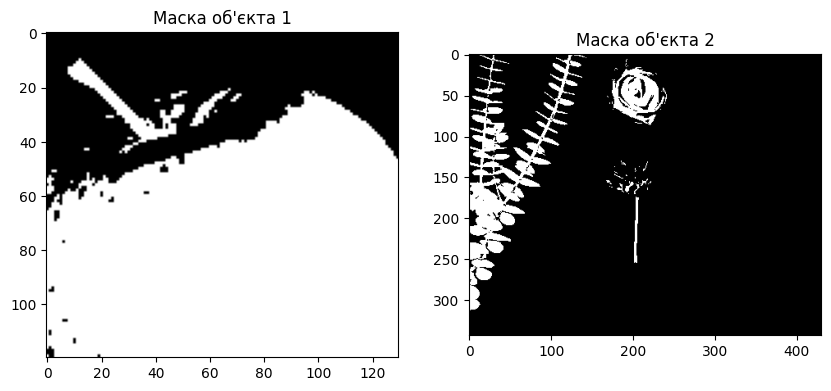

In [ ]:
# Знаходимо поріг
threshold_1 = otsu_threshold(img_gray1*255.0)
threshold_2 = otsu_threshold(img_gray2*255.0)

print(f"Крок 4: Знайдений поріг 1 (метод Отсу): {threshold_1}")
print(f"Крок 4: Знайдений поріг 2 (метод Отсу): {threshold_2}")

# Створюємо бінарну маску
# Припускаємо, що об'єкт світліший за фон
binary_mask_1 = (img_gray1 <= threshold_1/255)
binary_mask_2 = (img_gray2 <= threshold_2/255)


plt.subplot(1, 2, 1)
plt.imshow(binary_mask_1, cmap='gray')
plt.title("Маска об'єкта 1")
plt.subplot(1, 2, 2)
plt.imshow(binary_mask_2, cmap='gray')
plt.title("Маска об'єкта 2")
plt.show()

#### Крок 5: Вирізання об'єкта та перенесення на новий фон

In [302]:
# Створюємо копії маски для кожного з 3 каналів
mask_3d_1 = np.stack([binary_mask_1] * 3, axis=-1)
mask_3d_2 = np.stack([binary_mask_2] * 3, axis=-1)

# Копіюємо зображення фону, щоб не змінювати оригінал
result_image_1 = np.copy(img_background)
result_image_2 = np.copy(img_background)

#### Розміщення об'єкта на фоні

In [303]:
# Визначаємо реальні межі вставки першого зображення на фоні
y_offset = 100
x_offset = 300

# Визначаємо реальні межі вставки другого зображення на фоні
y2_offset = 50 
x2_offset = 200 

obj1_h, obj1_w, _ = img_cropped.shape   # Отримуємо розміри об'єкта 1
obj2_h, obj2_w, _ = img_cropped2.shape  # Отримуємо розміри об'єкта 2
bg_h, bg_w, _ = result_image_1.shape    # Отримуємо розміри фону

#### Захищаєм від виходу за межі фону 

In [304]:
# Визначаємо реальні межі вставки першого зображення на фоні
y1_start = y_offset
y1_end = min(y_offset + obj1_h, bg_h)
x1_start = x_offset
x1_end = min(x_offset + obj1_w, bg_w)

# Визначаємо реальні межі вставки другого зображення на фоні
y2_start = y2_offset
y2_end = min(y2_offset + obj2_h, bg_h)
x2_start = x2_offset
x2_end = min(x2_offset + obj2_w, bg_w)

In [305]:
obj_y_end_1 = y1_end - y1_start  # Визначаємо, яку частину об'єкта 1 та маски потрібно копіювати
obj_x_end_1 = x1_end - x1_start

obj_y_end_2 = y2_end - y2_start  # Визначаємо, яку частину об'єкта 2 та маски потрібно копіювати
obj_x_end_2 = x2_end - x2_start

# Вибираємо "шматки" для комбінування
region_on_bg_1 = result_image_1[y1_start:y1_end, x1_start:x1_end]
region_on_bg_2 = result_image_2[y2_start:y2_end, x2_start:x2_end]

object_to_paste_1 = img_cropped[:obj_y_end_1, :obj_x_end_1]
object_to_paste_2 = img_cropped2[:obj_y_end_2, :obj_x_end_2]

mask_to_use_1 = mask_3d_1[:obj_y_end_1, :obj_x_end_1]
mask_to_use_2 = mask_3d_2[:obj_y_end_2, :obj_x_end_2]

# Використовуємо np.where для комбінування:
composite_region_1 = np.where(mask_to_use_1, object_to_paste_1, region_on_bg_1)
composite_region_2 = np.where(mask_to_use_2, object_to_paste_2, region_on_bg_2)

# Вставляємо скомбінований регіон назад у фінальне зображення
result_image_1[y1_start:y1_end, x1_start:x1_end] = composite_region_1
result_image_2[y2_start:y2_end, x2_start:x2_end] = composite_region_2

#### Крок 6 відображення зображень

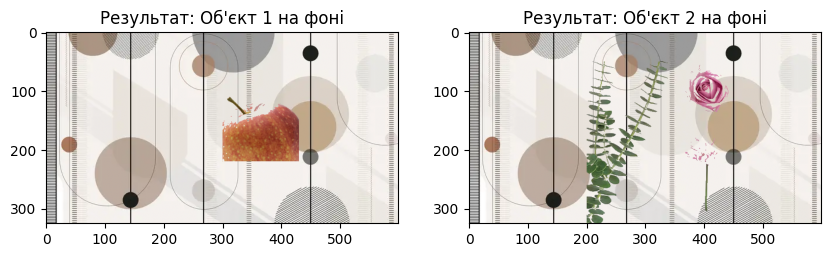

In [306]:
plt.subplot(1, 2, 1)
plt.imshow(result_image_1)
plt.title("Результат: Об'єкт 1 на фоні")
plt.subplot(1, 2, 2)
plt.imshow(result_image_2)
plt.title("Результат: Об'єкт 2 на фоні")
plt.show()

#### Збереження результату у файл. 

In [307]:
result_image_1_uint8 = (result_image_1 * 255).astype(np.uint8)
result_image_2_uint8 = (result_image_2 * 255).astype(np.uint8)

mpimg.imsave('result_1.png', result_image_1_uint8)
mpimg.imsave('result_2.png', result_image_2_uint8)
print("Результати збережено у файли 'result_1.png' та 'result_2.png'")

Результати збережено у файли 'result_1.png' та 'result_2.png'
